In [1]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.datasets import Food101
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler
from google.colab import drive

In [2]:
# Initialize Transforms

# Augment and Normalize training data
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Normalize Testing data -- skipping augmentation for appropriate performance measurement
test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


In [3]:
# Load data with official splits augmented per transforms
train_dataset = Food101(root="./data", split="train", transform=train_transform, download=True)
test_dataset  = Food101(root="./data", split="test",  transform=test_transform,  download=True)


100%|██████████| 5.00G/5.00G [00:33<00:00, 150MB/s]


In [4]:
# Wrap with dataloaders
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True, num_workers = 4)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = True, num_workers = 4)

In [5]:
# Load pretrained model EfficientNetV2-S
model = models.efficientnet_v2_s(weights = "IMAGENET1K_V1")

# tailor classification layer
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 101)

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 203MB/s]


In [6]:
# Attempt transition to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [7]:
# Defien Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=3e-4)

In [8]:
# Initialize learning rate scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size = 5, gamma = 0.1)

In [9]:
# enable mixed precision training
scaler = torch.amp.GradScaler('cuda')

In [10]:
# set up checkpointing to drive
drive.mount('/content/drive')
checkpoint_path = "/content/drive/MyDrive/CPSC8740/food101_checkpoint.pth"

# Create the directory if it doesn't exist
os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)


Mounted at /content/drive


Preliminary Steps are now in place. The training loop will now begin

In [11]:
num_epochs = 20
best_val_loss = float('inf')
patience = 5
patience_counter = 0

for epoch in range(num_epochs):
  # Training
  model.train()
  running_loss = 0.0
  correct = 0
  total = 0

  for images_batch, labels_batch in train_loader:
    images = images_batch.to(device) # images is now float32 on GPU
    labels = labels_batch.to(device)
    optimizer.zero_grad()

    # mixed precision forward pass
    with torch.amp.autocast('cuda'):
      outputs = model(images)
      loss = criterion(outputs, labels)

    # mixed precision backward passs
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()

    running_loss += loss.item()
    _, predicted = outputs.max(1)
    total += labels.size(0)
    correct += predicted.eq(labels).sum().item()

  train_acc = 100. * correct / total
  train_loss = running_loss / len(train_loader)

  # Validation
  model.eval()
  val_loss = 0.0
  correct = 0
  total = 0

  with torch.no_grad():
    for images_batch, labels_batch in test_loader:
      images = images_batch.to(device) # images is now float32 on GPU
      labels = labels_batch.to(device)
      # Let autocast handle type conversion for operations during validation
      outputs = model(images)
      loss = criterion(outputs, labels)

      val_loss += loss.item()
      _, predicted = outputs.max(1)
      total += labels.size(0)
      correct += predicted.eq(labels).sum().item()

  val_acc = 100. * correct/total
  val_loss = val_loss / len(test_loader)

  scheduler.step()

  # Early stopping mechanism to avoid redundant computing
  if val_loss < best_val_loss:
    best_val_loss = val_loss
    patience_counter = 0
    torch.save(model.state._dict(), checkpoint_path)
  else:
    patience_counter +=1
    if patience_counter >= patience:
      print(f"Early stopping triggered at epoch {epoch+1}")
      break

  # Document Statistics
  print(f"Epoch {epoch+1}/{num_epochs}")
  print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
  print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

  # # Record in checkpoint in drive
  # torch.save({
  #     "epoch": epoch,
  #     "model_state_dict": model.state_dict(),
  #     "optimizer_state_dict": optimizer.state_dict(),
  #     "val_acc": val_acc
  # }, checkpoint_path)

Epoch 1/20
Train Loss: 1.8712, Train Acc: 54.10%
Val Loss: 0.7387, Val Acc: 79.47%
Epoch 2/20
Train Loss: 1.2779, Train Acc: 67.15%
Val Loss: 0.6444, Val Acc: 82.34%
Epoch 3/20
Train Loss: 1.1307, Train Acc: 70.91%
Val Loss: 0.5661, Val Acc: 84.27%
Epoch 4/20
Train Loss: 1.0304, Train Acc: 73.17%
Val Loss: 0.5461, Val Acc: 84.52%
Epoch 5/20
Train Loss: 0.9712, Train Acc: 74.55%
Val Loss: 0.5008, Val Acc: 85.77%
Epoch 6/20
Train Loss: 0.7324, Train Acc: 80.53%
Val Loss: 0.3926, Val Acc: 88.87%
Epoch 7/20
Train Loss: 0.6356, Train Acc: 82.95%
Val Loss: 0.3858, Val Acc: 89.17%
Epoch 8/20
Train Loss: 0.5926, Train Acc: 84.04%
Val Loss: 0.3761, Val Acc: 89.45%
Epoch 9/20
Train Loss: 0.5645, Train Acc: 84.73%
Val Loss: 0.3704, Val Acc: 89.82%
Epoch 10/20
Train Loss: 0.5390, Train Acc: 85.49%
Val Loss: 0.3757, Val Acc: 89.70%
Epoch 11/20
Train Loss: 0.5050, Train Acc: 86.33%
Val Loss: 0.3735, Val Acc: 89.77%
Epoch 12/20
Train Loss: 0.5065, Train Acc: 86.39%
Val Loss: 0.3711, Val Acc: 89.75%
E

Model Evaluation

                         precision    recall  f1-score   support

              apple_pie       0.82      0.76      0.79       250
         baby_back_ribs       0.93      0.90      0.92       250
                baklava       0.96      0.94      0.95       250
         beef_carpaccio       0.94      0.93      0.94       250
           beef_tartare       0.86      0.90      0.88       250
             beet_salad       0.84      0.85      0.85       250
               beignets       0.92      0.94      0.93       250
               bibimbap       0.97      0.94      0.96       250
          bread_pudding       0.78      0.76      0.77       250
      breakfast_burrito       0.83      0.85      0.84       250
             bruschetta       0.92      0.84      0.88       250
           caesar_salad       0.89      0.93      0.91       250
                cannoli       0.92      0.96      0.94       250
          caprese_salad       0.89      0.92      0.91       250
            carrot_cake 

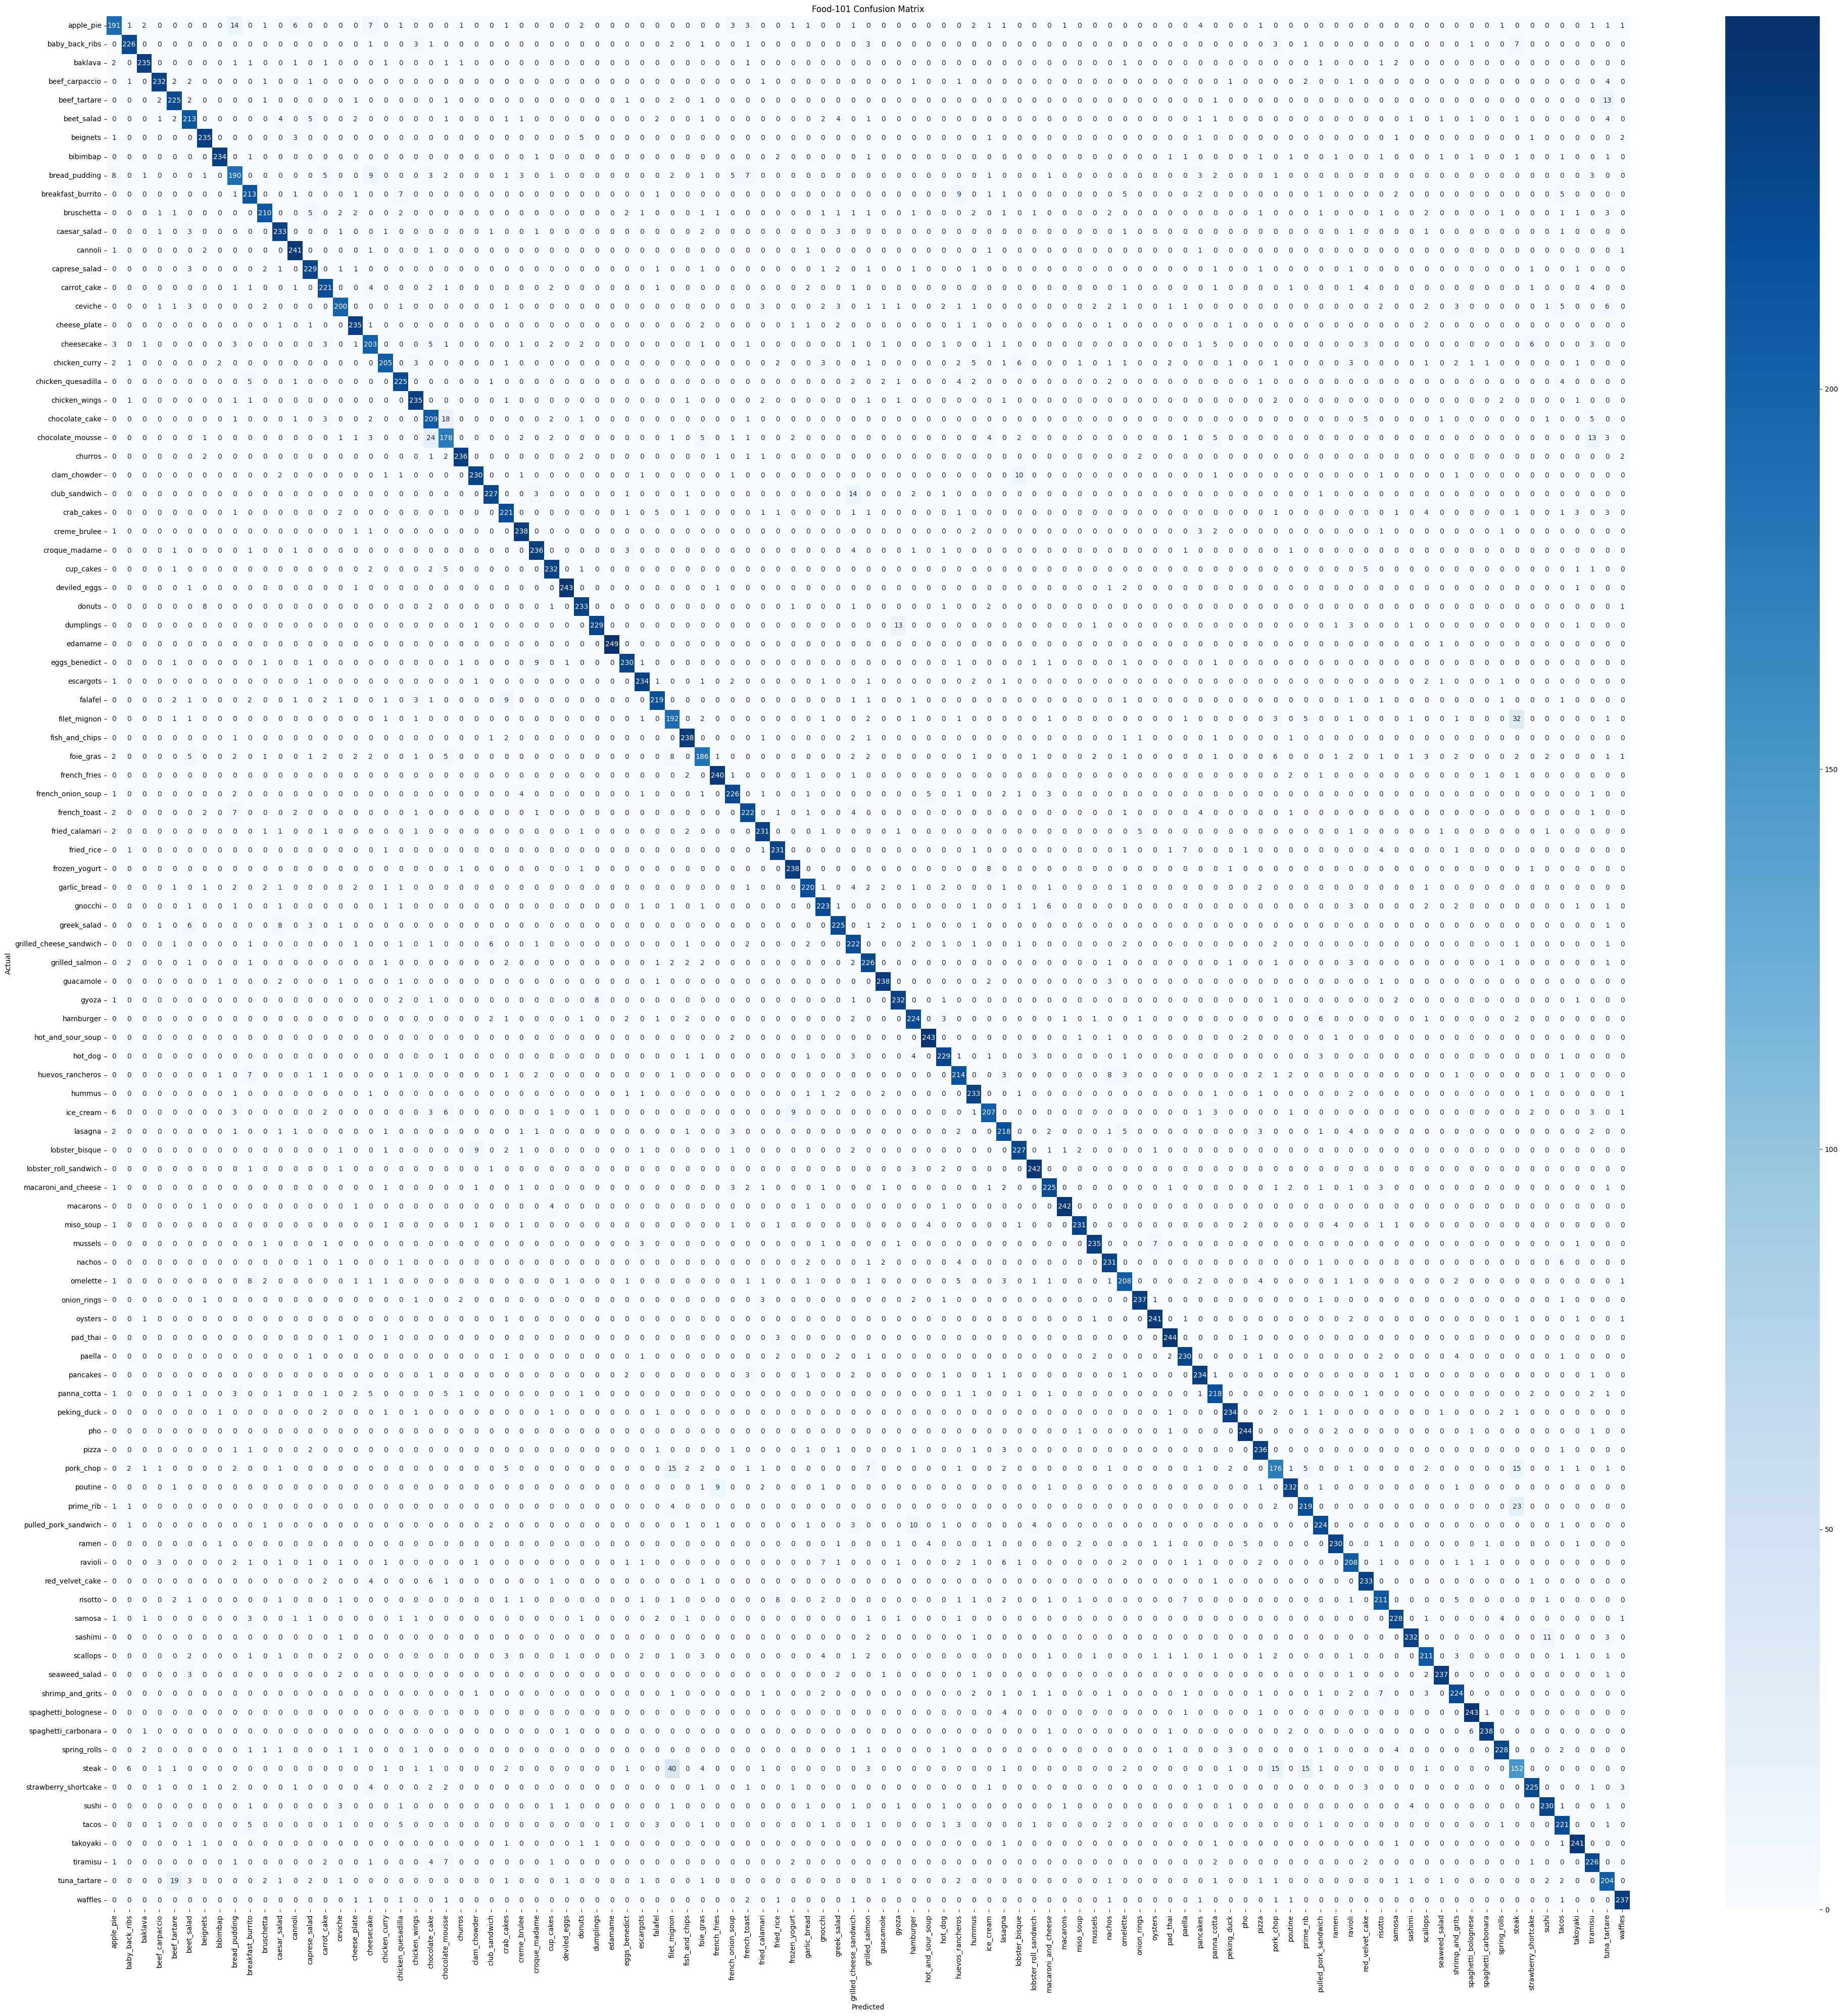

In [12]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Collect all predictions and labels
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images_batch, labels_batch in test_loader:
        images = images_batch.to(device)
        labels = labels_batch.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Classification Report
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(40, 40))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            xticklabels=test_dataset.classes,
            yticklabels=test_dataset.classes,
            cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Food-101 Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

Export

In [14]:
checkpoint = torch.load(checkpoint_path)
model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

In [16]:
# download as PyTorch model
from google.colab import files

torch.save(model.state_dict(), "food101_efficientnetv2s.pth")
files.download("food101_efficientnetv2s.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>